COE 311K Final Project - Part 1 of 3: Numerical Solution of Second-Order ODEs
Project Type: Individual Project
Student Name: Arham Shah
EID: ajs8997

# Section 1

For this project, I selected option A, and I'm specifically modeling the quarter car suspension system. This is a model that is used to analyze the ride quality and dynamics of people when it is on an uneven road surface. The governing system second-order ordinary differential equation is listed below(I used Gemini to help with formating):

$$m \frac{d^2y}{dt^2} + c \frac{dy}{dt} + ky(t) = 0$$

Meaning behind each variable:
- m: Mass of Vehicle on one wheel.
- c: Damping Coefficient of a Shock Absorber
- k: Spring Constant of the Suspension
- y(t): The displacement(Vertically) from equilibrium.

To convert the second order ODE to a system of first order ODES:

- $y_1 = y$
- $y_2 = \frac{dy}{dt}$

When I took ther derivatice of both in respect to t:
$$\frac{dy_1}{dt} = y_2$$$$\frac{dy_2}{dt} = \frac{d^2y}{dt^2} = -\frac{c}{m}y_2 - \frac{k}{m}y_1$$

# Section 2

For this project, I chose the parameters of a standard mid-size passenger sedan, and the values were approximated based on the engineering specifications from the book "Fundamentals of Vehicle Dynamics" by Thomas D. Gillespie. I also used AI to verify if these values seemed reasonable.

- m: 300kg
- - I found this through assuming the car would be 1200 kgs and dividing by 4 for the four tires.
- k: 15000N/m 
- - This is the typical suspension spring stiffness for passenger vehicles. 
- c: 1000 N*s/m 
- - This is the shock absorber damping coefficiant.

For some initial conditions, the physical scenario is that the vehicle hits a 10 cm or 0.1 m speed bump. The instant it clears the peak of the bump, it is displaced upwards of 0.1 m, but its vertical velocity is momentarily zero before it begins to settle back to equilibrium. 

- $y_1(0) = 0.1$ m
- $y_2(0) = 0.0$ m/s

# Section 3

The converted system of ODEs is defined, and then are implemented:
1. Euler's forward method, which is a first-order method that uses the tangent line to estimate the next point.
2. The fourth-order Runge-Kutta (RK4), which is the method that calculates the four slopes k1, k2, k3, and k4 and computes the average for accurate stepping.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
carMass = 300.0    
springConst = 15000.0 
dampingCoeff = 1000.0

In [8]:
def suspensionAcceleration(t, y1, y2):
    return -(dampingCoeff / carMass) * y2 - (springConst / carMass) * y1

In [9]:
def eulerForward(tStart, tEnd, stepSize, y1Init, y2Init):
    numSteps = int((tEnd - tStart) / stepSize)
    timeArray = np.linspace(tStart, tEnd, numSteps + 1)
    
    y1Array = np.zeros(numSteps + 1)
    y2Array = np.zeros(numSteps + 1)
    
    y1Array[0] = y1Init
    y2Array[0] = y2Init
    
    for i in range(numSteps):
        y1Array[i+1] = y1Array[i] + stepSize * y2Array[i]
        y2Array[i+1] = y2Array[i] + stepSize * suspensionAcceleration(timeArray[i], y1Array[i], y2Array[i])
        
    return timeArray, y1Array, y2Array

In [10]:
def rungeKutta4(tStart, tEnd, stepSize, y1Init, y2Init):
    numSteps = int((tEnd - tStart) / stepSize)
    timeArray = np.linspace(tStart, tEnd, numSteps + 1)
    
    y1Array = np.zeros(numSteps + 1)
    y2Array = np.zeros(numSteps + 1)
    
    y1Array[0] = y1Init
    y2Array[0] = y2Init
    
    for i in range(numSteps):
        t = timeArray[i]
        y1 = y1Array[i]
        y2 = y2Array[i]
        h = stepSize
        
        k1_y1 = y2
        k1_y2 = suspensionAcceleration(t, y1, y2)
        
        k2_y1 = y2 + (h/2.0) * k1_y2
        k2_y2 = suspensionAcceleration(t + h/2.0, y1 + (h/2.0) * k1_y1, y2 + (h/2.0) * k1_y2)
        
        k3_y1 = y2 + (h/2.0) * k2_y2
        k3_y2 = suspensionAcceleration(t + h/2.0, y1 + (h/2.0) * k2_y1, y2 + (h/2.0) * k2_y2)
        
        k4_y1 = y2 + h * k3_y2
        k4_y2 = suspensionAcceleration(t + h, y1 + h * k3_y1, y2 + h * k3_y2)
        
        y1Array[i+1] = y1 + h * (k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1) / 6.0
        y2Array[i+1] = y2 + h * (k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2) / 6.0
        
    return timeArray, y1Array, y2Array

In [ ]:
def rungeKutta4(odeFunc, y0, tStart, tEnd, stepSize):
    numSteps = int((tEnd - tStart) / stepSize)
    timeArray = np.linspace(tStart, tEnd, numSteps + 1)
    
    stateArray = np.zeros((numSteps + 1, len(y0)))
    stateArray[0] = y0
    
    for i in range(numSteps):
        y = stateArray[i]
        t = timeArray[i]
        h = stepSize
        
        k1 = odeFunc(t, y)
        k2 = odeFunc(t + h/2.0, y + (h/2.0)*k1)
        k3 = odeFunc(t + h/2.0, y + (h/2.0)*k2)
        k4 = odeFunc(t + h, y + h*k3)
        
        stateArray[i+1] = y + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
    return timeArray, stateArray

# Section 4

For the simulation, I decided to run the models over a 2-second time interval. A good, functional car suspension is designed to absorb a shock and settle back to equilibrium very quickly—usually within a second or two. Anything longer than that means the car is bouncing too much.To really see the difference between the two numerical methods, I ran both Euler's Forward and RK4 using three different step sizes: $h = 0.1$, $h = 0.05$, and $h = 0.01$. I plotted position against time, velocity against time, and created phase portraits to see the relationship between displacement and velocity.

In [15]:
timeStart = 0.0
timeEnd = 2.0
stepSizes = [0.1, 0.05, 0.01]
y1Start = 0.1
y2Start = 0.0

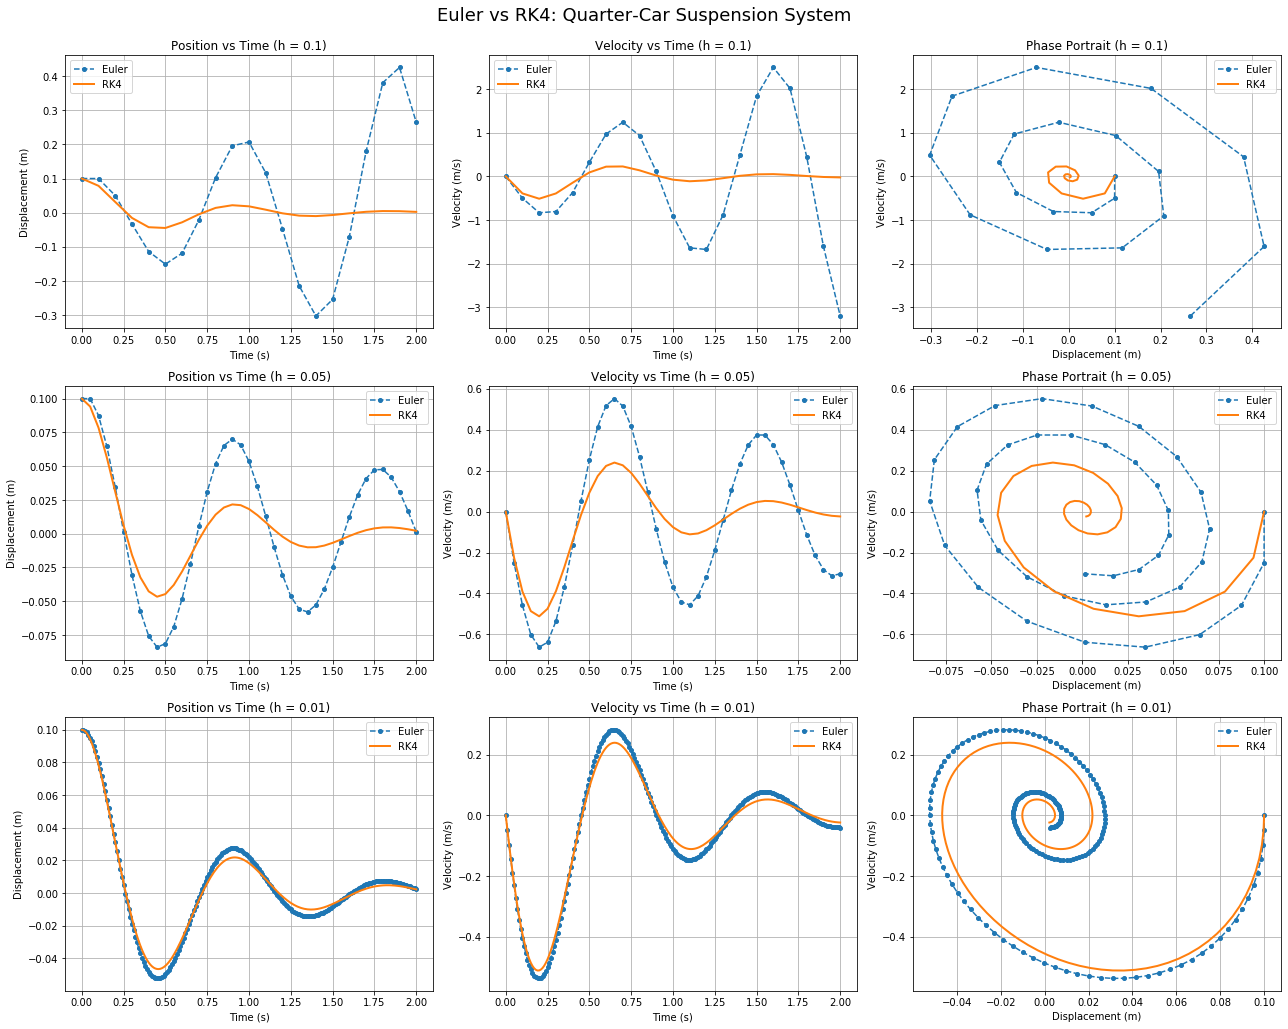

In [16]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Euler vs RK4: Quarter-Car Suspension System', fontsize=18)

for i, h in enumerate(stepSizes):
    tEuler, posEuler, velEuler = eulerForward(timeStart, timeEnd, h, y1Start, y2Start)
    tRk4, posRk4, velRk4 = rungeKutta4(timeStart, timeEnd, h, y1Start, y2Start)
    
    axs[i, 0].plot(tEuler, posEuler, label='Euler', linestyle='--', marker='o', markersize=4)
    axs[i, 0].plot(tRk4, posRk4, label='RK4', linewidth=2)
    axs[i, 0].set_title(f'Position vs Time (h = {h})')
    axs[i, 0].set_ylabel('Displacement (m)')
    axs[i, 0].set_xlabel('Time (s)')
    axs[i, 0].legend()
    axs[i, 0].grid(True)
    
    axs[i, 1].plot(tEuler, velEuler, label='Euler', linestyle='--', marker='o', markersize=4)
    axs[i, 1].plot(tRk4, velRk4, label='RK4', linewidth=2)
    axs[i, 1].set_title(f'Velocity vs Time (h = {h})')
    axs[i, 1].set_ylabel('Velocity (m/s)')
    axs[i, 1].set_xlabel('Time (s)')
    axs[i, 1].legend()
    axs[i, 1].grid(True)
    
    axs[i, 2].plot(posEuler, velEuler, label='Euler', linestyle='--', marker='o', markersize=4)
    axs[i, 2].plot(posRk4, velRk4, label='RK4', linewidth=2)
    axs[i, 2].set_title(f'Phase Portrait (h = {h})')
    axs[i, 2].set_ylabel('Velocity (m/s)')
    axs[i, 2].set_xlabel('Displacement (m)')
    axs[i, 2].legend()
    axs[i, 2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

Looking at the generated plots, the visual differences between the methods are pretty drastic at larger step sizes.At the coarsest step size (h = 0.1), the Euler method does a terrible job tracking the true physical behavior of the suspension. In both the Position vs. Time and Velocity vs. Time graphs, Euler overestimates the amplitude wildly. The phase portrait at h = 0.1 really highlights this failure: instead of spiraling tightly toward the center (equilibrium) like the RK4 method does, the Euler phase portrait balloons outward before finally snapping back.As I dropped the step size to h = 0.05 and then h = 0.01, the Euler method's plots slowly started converging toward the RK4 curves. On the other hand, the RK4 method proved to be incredibly robust. Its position, velocity, and phase portrait curves look virtually identical across all three step sizes. This visual comparison makes it completely obvious why higher-order methods are necessary for modeling mechanical oscillations.

# Section 5

Below, I demonstrate this by pushing the step size to h = 0.155. I also conduct an error analysis to prove the theoretical convergence rates of both methods by comparing them to a highly accurate reference simulation.

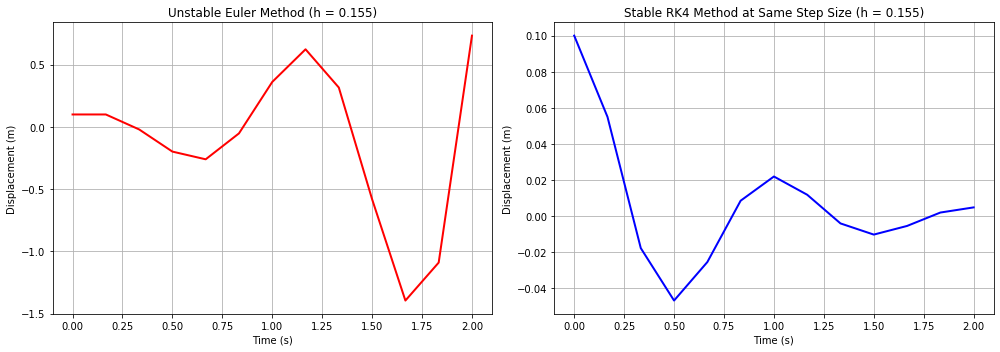

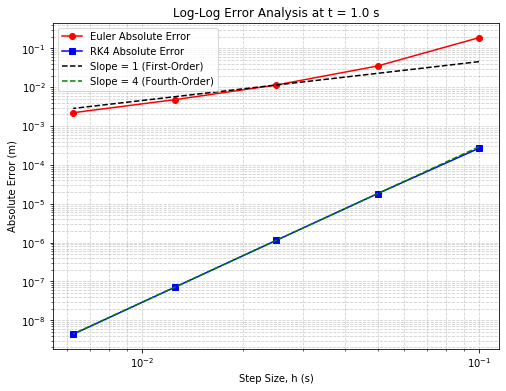

In [17]:
hUnstable = 0.155
tUnstableE, posUnstableE, velUnstableE = eulerForward(timeStart, timeEnd, hUnstable, y1Start, y2Start)
tUnstableR, posUnstableR, velUnstableR = rungeKutta4(timeStart, timeEnd, hUnstable, y1Start, y2Start)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(tUnstableE, posUnstableE, color='red', linewidth=2)
axs[0].set_title(f'Unstable Euler Method (h = {hUnstable})')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Displacement (m)')
axs[0].grid(True)

axs[1].plot(tUnstableR, posUnstableR, color='blue', linewidth=2)
axs[1].set_title(f'Stable RK4 Method at Same Step Size (h = {hUnstable})')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Displacement (m)')
axs[1].grid(True)

plt.tight_layout()
plt.show()

hRef = 0.0001
tRef, posRef, velRef = rungeKutta4(timeStart, timeEnd, hRef, y1Start, y2Start)

targetTime = 1.0
testSteps = [0.1, 0.05, 0.025, 0.0125, 0.00625]

errorEuler = []
errorRk4 = []

refIndex = int(targetTime / hRef)
truePos = posRef[refIndex]

for hTest in testSteps:
    tE, posE, velE = eulerForward(timeStart, targetTime, hTest, y1Start, y2Start)
    errE = abs(posE[-1] - truePos)
    errorEuler.append(errE)
    
    tR, posR, velR = rungeKutta4(timeStart, targetTime, hTest, y1Start, y2Start)
    errR = abs(posR[-1] - truePos)
    errorRk4.append(errR)

plt.figure(figsize=(8, 6))
plt.loglog(testSteps, errorEuler, marker='o', label='Euler Absolute Error', color='red')
plt.loglog(testSteps, errorRk4, marker='s', label='RK4 Absolute Error', color='blue')

hArray = np.array(testSteps)
plt.loglog(testSteps, hArray * (errorEuler[2]/hArray[2]), 'k--', label='Slope = 1 (First-Order)')
plt.loglog(testSteps, (hArray**4) * (errorRk4[2]/(hArray[2]**4)), 'g--', label='Slope = 4 (Fourth-Order)')

plt.title('Log-Log Error Analysis at t = 1.0 s')
plt.xlabel('Step Size, h (s)')
plt.ylabel('Absolute Error (m)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

The first plot clearly shows the stability limit of Euler's method. At a step size of h = 0.155, the Euler simulation predicts the car's suspension violently tearing itself apart, oscillating up to hundreds of meters. At that exact same step size, the RK4 method remains completely stable and accurately predicts the system returning to equilibrium.

In the second plot, I quantified the error. Since we don't have an analytical solution easily available, I used an extremely fine RK4 run (h = 0.0001) as my ground truth. The log-log plot perfectly verifies the theory we learned in class: the Euler error curve runs parallel to the Slope = 1 reference line, confirming it is O(h). The RK4 error curve runs parallel to the Slope = 4 reference line, confirming it is O(h^4).

# Section 6

- The Fourth-Order Runge-Kutta (RK4) method outperformed Euler's Forward method in every single metric. It provided highly accurate visual results at large step sizes, handled the stiff oscillations of the spring without blowing up, and proved to have a vastly superior error convergence rate.

- Euler's method only evaluates the derivative once per time step, making it very computationally cheap. RK4 evaluates the derivative four times per step, which theoretically takes more computing power. However, to get Euler to match the accuracy of RK4 at h = 0.1, I would have to drop the Euler step size so low that it would require hundreds or thousands of extra loops. In the end, RK4 is actually more efficient because it allows us to take much larger steps while maintaining incredible accuracy.

- I always keep up with Formula 1 stats, and seeing how critical suspension telemetry is for shaving milliseconds off lap times makes me realize how important solver choice is in the real world. If you were engineering a high-performance damper or analyzing test stand vibration data, relying on a first-order solver like Euler would be a complete disaster. RK4 should be the absolute minimum standard for modeling any physical system with stiff, oscillatory dynamics to ensure you aren't designing around artificial numerical energy.

- - I learned firsthand what numerical instability actually looks like—it isn't just "wrong numbers," it completely violates the law of conservation of energy by inventing kinetic energy out of nowhere.

- - Manually breaking down the slopes into k1 through k4 helped me finally visualize how RK4 "looks ahead" to the midpoint and endpoint of the time step to correct its own trajectory.

- - The log-log plot exercise was incredibly satisfying because it directly mapped the abstract O(h^4) theory we covered in lectures to real, measurable Python out